## Extended Data Figure 4: mCherry 

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib.ticker import ScalarFormatter
from pathlib import Path
import seaborn as sns
import re
from statannotations.Annotator import Annotator
import rushd as rd
import matplotlib
from scipy.optimize import curve_fit
from scipy.stats import poisson
from scipy.optimize import fsolve
from matplotlib.patches import Patch

In [2]:
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.02.22_DASIT_mCH_ALFA_rep1': ['Plate1'],
'2026.02.23_DASIT_mCH_ALFA_rep2_3': ['Plate1_3dpi_rep2_3', 'Plate2_4dpi_rep1', 'Plate3_3dpi_rep2_3_control'],
'2026.02.24_DASIT_mCH_ALFA_rep2_3': ['Plate1', 'Plate2'],
          }

In [3]:
exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'export_singlets')
        yaml_path.append(base_path/i/j/'export_singlets'/'well_metadata.yaml')

output_path = rd.rootdir/'output'/'ExtFig4'
cache_path = rd.rootdir/'output'/'ExtFig4'/'data_mcherry.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
3,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
4,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
5,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


In [4]:
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mCherry-A','mCherry-H', 'FSC-A', 'SSC-A', 'TagBFP-A','TagBFP-H', 'iRFP670-A','iRFP670-H']
    data = rd.flow.load_groups_with_metadata(plates_dict, columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove negative values from dataframe
    for c in channel_list: data = data[data[c] > 0]

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))
display(data)

,reporter,Label,dpi,Date,well,population,FSC-A,SSC-A,iRFP670-A,iRFP670-H,TagBFP-A,TagBFP-H,mCherry-A,mCherry-H
1,Untransfected,None,3dpi,2026.02.22.x,A10,Single Cells,447285.0,120220.0,58.0,61,114,101,53,69
5,Untransfected,None,3dpi,2026.02.22.x,A10,Single Cells,346034.0,168231.0,46.0,85,25,73,62,92
8,Untransfected,None,3dpi,2026.02.22.x,A10,Single Cells,405264.0,240577.0,83.0,106,51,92,122,95
10,Untransfected,None,3dpi,2026.02.22.x,A10,Single Cells,229688.0,181705.0,82.0,80,69,67,134,63
11,Untransfected,None,3dpi,2026.02.22.x,A10,Single Cells,524408.0,205755.0,23.0,51,2,71,88,141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18309403,None.Untransfected,None,4dpi,2026.02.24.xx,H3,Single Cells,322840.0,201437.0,142.0,115,96,111,163,90
18309404,None.Untransfected,None,4dpi,2026.02.24.xx,H3,Single Cells,314038.0,360408.0,548.0,378,324,226,167,193
18309406,None.Untransfected,None,4dpi,2026.02.24.xx,H3,Single Cells,333479.0,431807.0,323.0,290,62,49,216,188
18309408,None.Untransfected,None,4dpi,2026.02.24.xx,H3,Single Cells,192598.0,165130.0,353.0,213,65,109,151,144


In [5]:
data['conds'] = data['reporter'] + '.' + data['Label']

**Plot mCherry labeled 293Ts**

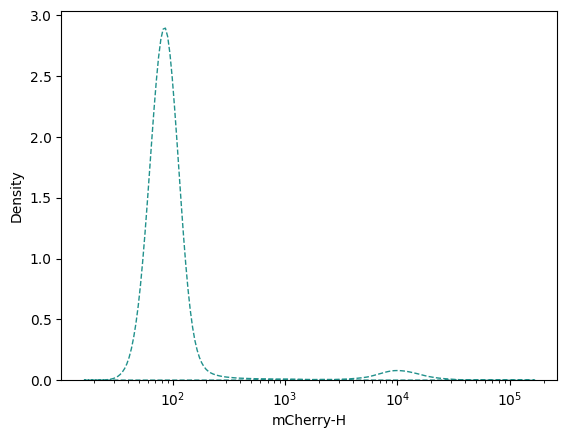

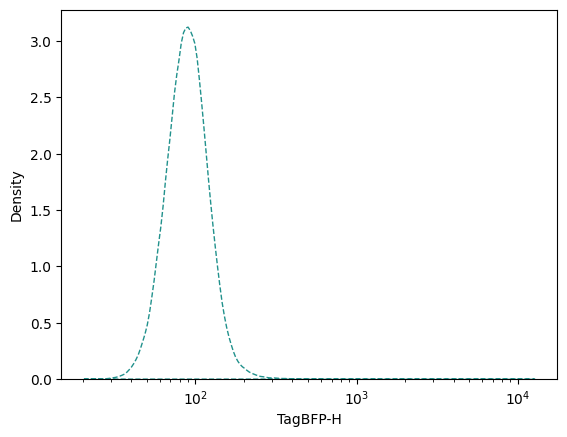

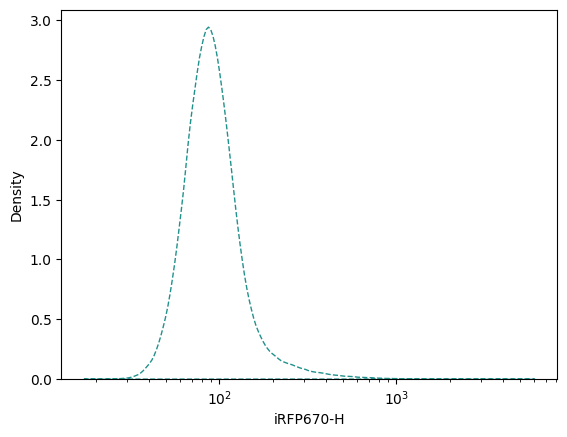

In [6]:
untransfected = data[(data['Label'] == 'mCH') & (data['reporter'] == 'None')]
parameters = np.array(['mCherry-H', 'TagBFP-H', 'iRFP670-H'])
for param in parameters:
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='reporter',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

**Set gates for FPs**

In [7]:
TagBFP_gate = 1000
iRFP_gate = 1000
mCherry_gate = 1000

**Selecting only mCherry constructs and for transduced cells (iRFP+)**

In [8]:
mCH_4dpi = data[ (data['reporter'] != 'wtNB_ALFA') & (data['reporter'] != 'desNB_ALFA') & (data['reporter'] != 'Untransfected')& (data['dpi'] == '4dpi')].copy()
gated_mCH_4dpi = data[(data['iRFP670-H'] > iRFP_gate) & (data['reporter'] != 'wtNB_ALFA') & (data['reporter'] != 'desNB_ALFA') & (data['reporter'] != 'Untransfected')& (data['dpi'] == '4dpi')].copy()

## Extended Data Figure 4F

**Extended Data Figure 4F**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_26924\3878411774.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()  # Helps improve white spacing


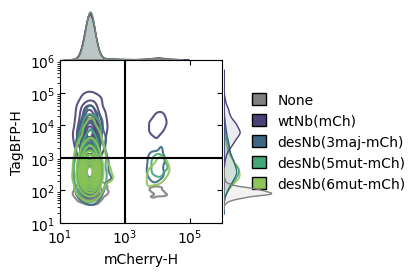

In [9]:
# General plotting params
y = "TagBFP-H"
x = "mCherry-H"
hue = "conds"
hue_order = ['None.mCH', 'wtNB_mCH.mCH', 'desNB_3mCH.mCH', 'desNB_5mCH.mCH', 'desNB_6mCH.mCH']
# Conditions
palette = {
    'None.mCH': 'grey',
    'wtNB_mCH.mCH': '#4B4279',
    'desNB_3mCH.mCH': '#3C6682',
    'desNB_5mCH.mCH': '#45A778',
    'desNB_6mCH.mCH': '#8FC456',
}

# Legend labels
label_map = {
    'None.mCH': 'None',
    'wtNB_mCH.mCH': 'wtNb(mCh)',
    'desNB_3mCH.mCH': 'desNb(3maj-mCh)',
    'desNB_5mCH.mCH': 'desNb(5mut-mCh)',
    'desNB_6mCH.mCH': 'desNb(6mut-mCh)',
}

# only look at no selection and iRFP+ infected
small_data = pd.concat([gated_mCH_4dpi, untransfected])
small_data= small_data.groupby('conds').sample(n=2000, random_state=7, replace=True)


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(2.5, 2.5))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
mRuby2_lim = (10, 1e6)
mCherry_lim = (10, 1e6)
ylim = mRuby2_lim
xlim = mCherry_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)

legend_handles = [
    Patch(
        facecolor=palette[cond],
        edgecolor='black',
        label=label_map[cond]
    )
    for cond in hue_order
]

ax_scatter.legend(
    handles=legend_handles,
    title='',
    loc='center left',
    bbox_to_anchor=(1.15, 0.5),
    frameon=False,
    handlelength=1,
    handleheight=1,
    borderaxespad=0,
)

# Threshold
ax_scatter.axvline(mCherry_gate, 0, 1, color='black')
ax_scatter.axhline(TagBFP_gate, 0, 1, color='black')

fig.tight_layout()  # Helps improve white spacing

plottitle = 'Extended_Data_Figure4F.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')